In [12]:
import itertools
import pandas as pd
import numpy as np

from aeon.datasets.tsc_datasets import multivariate

import seaborn as sns
import matplotlib.pyplot as plt

In [13]:
import pandas as pd

# Carregando os dados consolidados do arquivo Excel
df = pd.read_excel("resultados_finais/ResultadosFinais.xlsx")

# Verificando as primeiras linhas e informações básicas
print(f"Total de registros: {len(df)}")
print(f"Datasets únicos: {len(df['dataset'].unique())}")
print(f"Colunas disponíveis: {list(df.columns)}")
print("\nPrimeiras linhas:")
df.head()

Total de registros: 954
Datasets únicos: 26
Colunas disponíveis: ['dataset', 'representation', 'representation_transform_time', 'concatenation_type', 'accuracy', 'convolution_algorithm', 'convolution_time', 'classification_algorithm', 'train_time', 'validation_time']

Primeiras linhas:


,dataset,representation,representation_transform_time,concatenation_type,accuracy,convolution_algorithm,convolution_time,classification_algorithm,train_time,validation_time
0,AtrialFibrillation,CWT,0.134481,pre_transform,0.400000,NaN,0.000000e+00,Ridge,0.010381,0.000531
1,AtrialFibrillation,CWT,0.134481,pre_transform,0.200000,Rocket,1.027527e+14,Ridge,0.008690,0.000968
2,AtrialFibrillation,CWT,0.134481,pre_transform,0.333333,MiniRocket,4.693351e-01,Ridge,0.007075,0.000921
3,AtrialFibrillation,CWT,0.092987,post_transform,0.333333,NaN,0.000000e+00,Ridge,0.001601,0.000326
4,AtrialFibrillation,CWT,0.092987,post_transform,0.333333,Rocket,5.019178e-01,Ridge,0.016172,0.001501


In [14]:
# Definindo as categorias disponíveis nos dados consolidados
representations = df['representation'].unique()
concatenation_types = df['concatenation_type'].unique()
convolution_algorithms = df['convolution_algorithm'].unique()
classification_algorithms = df['classification_algorithm'].unique()

print("Representações disponíveis:", representations)
print("Tipos de concatenação:", concatenation_types)
print("Algoritmos de convolução:", convolution_algorithms)
print("Algoritmos de classificação:", classification_algorithms)

Representações disponíveis: ['CWT' 'RP' 'MTF' 'GASF' 'GADF' 'FIRTS']
Tipos de concatenação: ['pre_transform' 'post_transform']
Algoritmos de convolução: [nan 'Rocket' 'MiniRocket']
Algoritmos de classificação: ['Ridge']


In [15]:
df

,dataset,representation,representation_transform_time,concatenation_type,accuracy,convolution_algorithm,convolution_time,classification_algorithm,train_time,validation_time
0,AtrialFibrillation,CWT,0.134481,pre_transform,0.400000,NaN,0.000000e+00,Ridge,0.010381,0.000531
1,AtrialFibrillation,CWT,0.134481,pre_transform,0.200000,Rocket,1.027527e+14,Ridge,0.008690,0.000968
2,AtrialFibrillation,CWT,0.134481,pre_transform,0.333333,MiniRocket,4.693351e-01,Ridge,0.007075,0.000921
3,AtrialFibrillation,CWT,0.092987,post_transform,0.333333,NaN,0.000000e+00,Ridge,0.001601,0.000326
4,AtrialFibrillation,CWT,0.092987,post_transform,0.333333,Rocket,5.019178e-01,Ridge,0.016172,0.001501
...,...,...,...,...,...,...,...,...,...,...
949,StandWalkJump,FIRTS,0.113150,pre_transform,0.600000,Rocket,1.940745e+00,Ridge,0.002347,0.000405
950,StandWalkJump,FIRTS,0.113150,pre_transform,0.733333,MiniRocket,1.250262e+00,Ridge,0.001839,0.000340
951,StandWalkJump,FIRTS,0.158670,post_transform,0.400000,NaN,0.000000e+00,Ridge,0.001509,0.000254
952,StandWalkJump,FIRTS,0.158670,post_transform,0.533333,Rocket,5.131276e-01,Ridge,0.002213,0.000409


## Por dataset

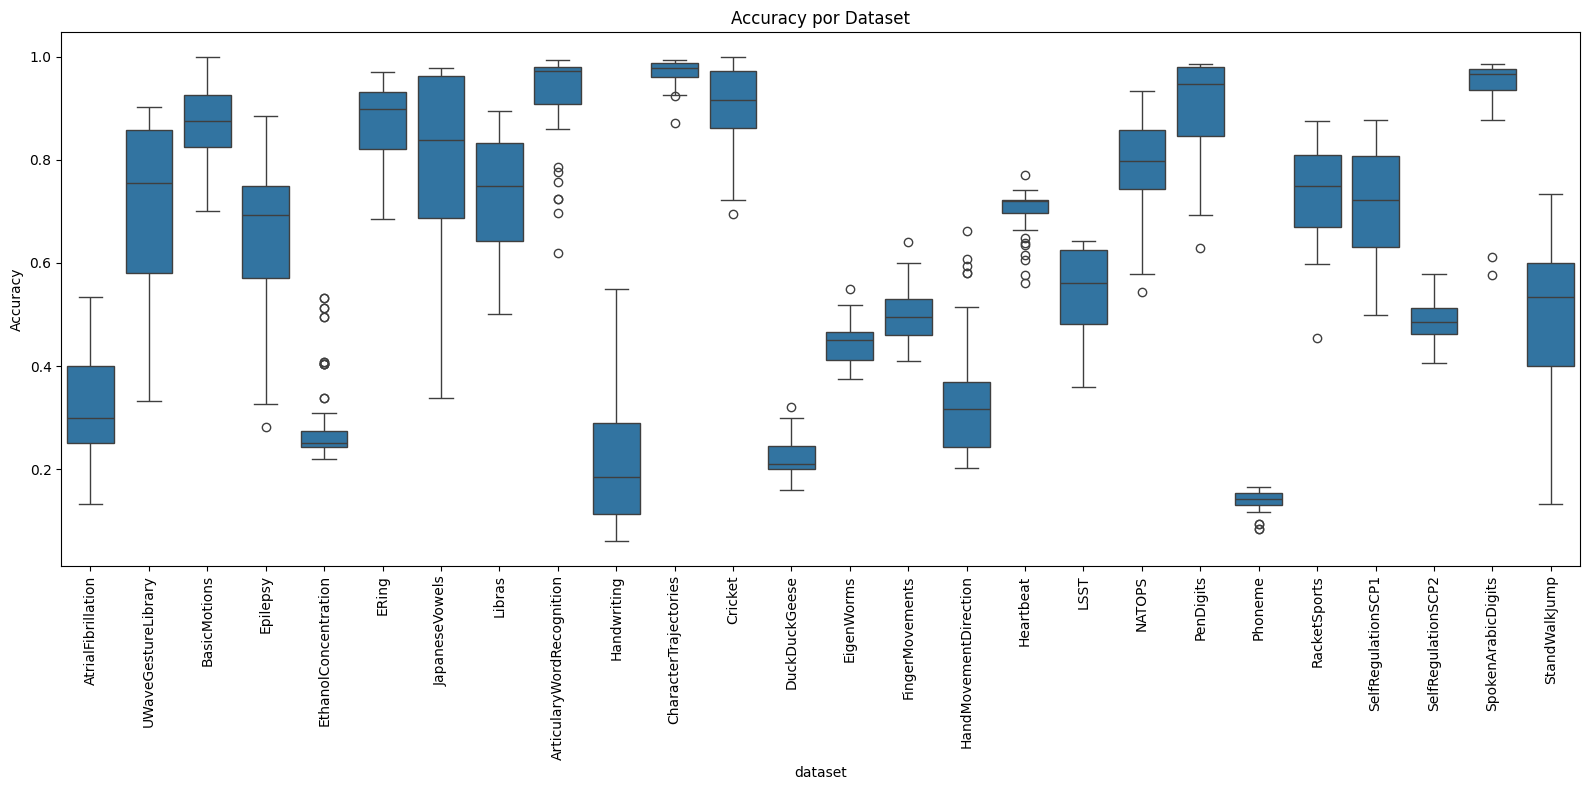

In [16]:
plt.figure(figsize=(16, 8))
plt.xticks(rotation=90)

sns.boxplot(x="dataset", y="accuracy", data=df)
plt.title("Accuracy por Dataset")
plt.ylabel("Accuracy")
plt.tight_layout()
plt.show()

## Por representação

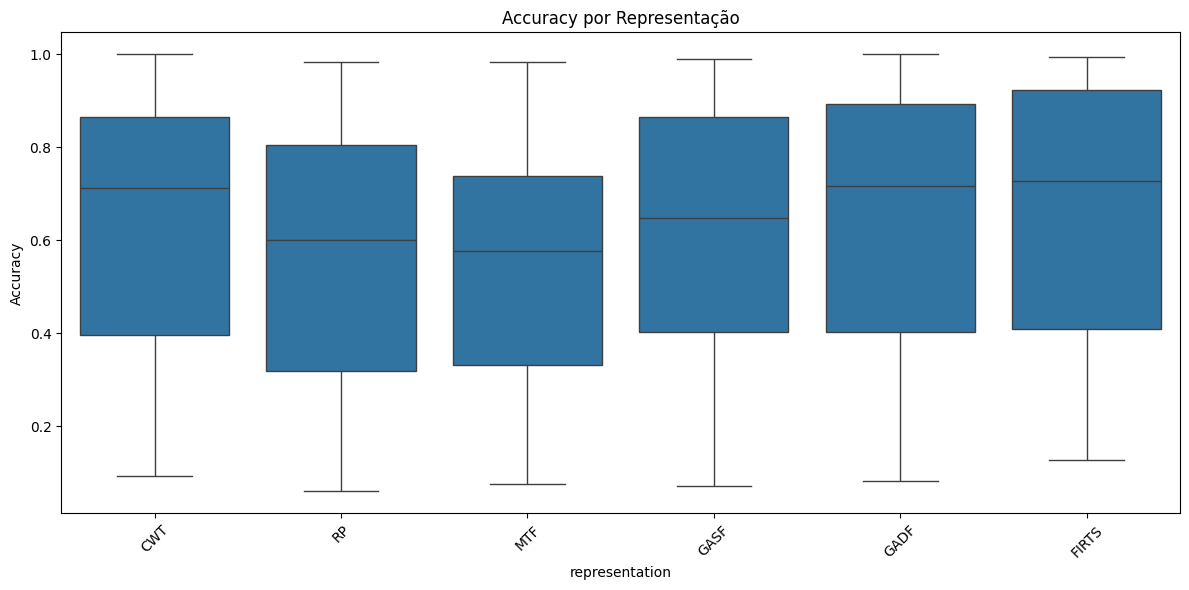

In [17]:
plt.figure(figsize=(12, 6))
sns.boxplot(x="representation", y="accuracy", data=df)
plt.title("Accuracy por Representação")
plt.xticks(rotation=45)
plt.ylabel("Accuracy")
plt.tight_layout()
plt.show()

## Por tipo de concatenação

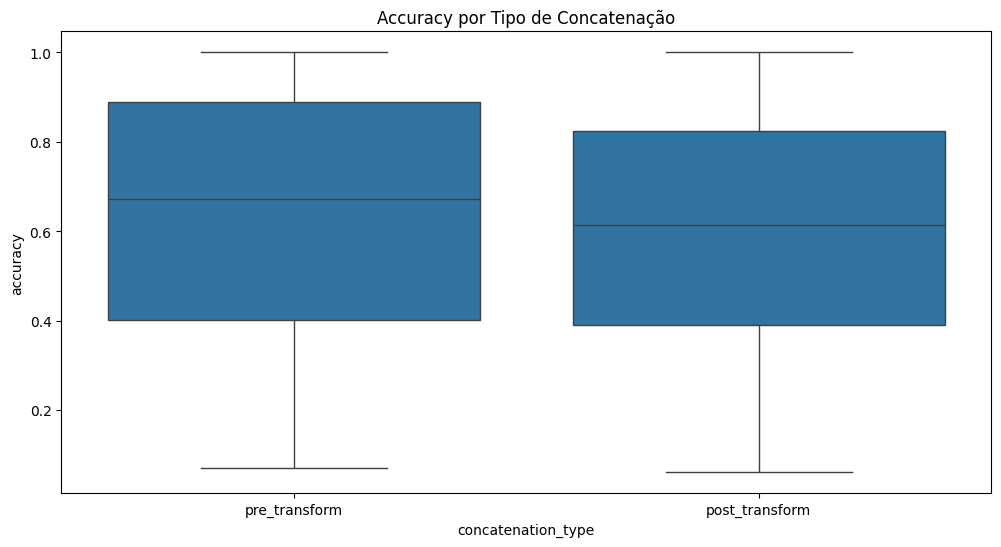

In [18]:
plt.figure(figsize=(12, 6))
sns.boxplot(x="concatenation_type", y="accuracy", data=df)
plt.title("Accuracy por Tipo de Concatenação")
plt.show()

## Por algoritmo de convolução

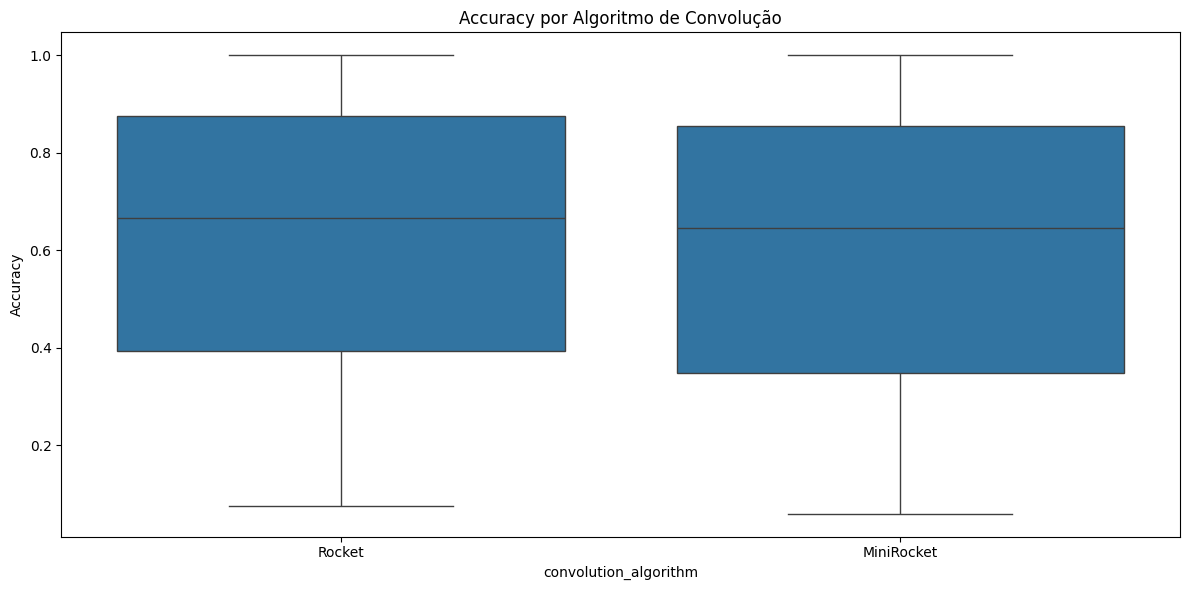

In [19]:
plt.figure(figsize=(12, 6))
sns.boxplot(x="convolution_algorithm", y="accuracy", data=df)
plt.title("Accuracy por Algoritmo de Convolução")
plt.ylabel("Accuracy")
plt.tight_layout()
plt.show()

## Por representação e tipo de concatenação

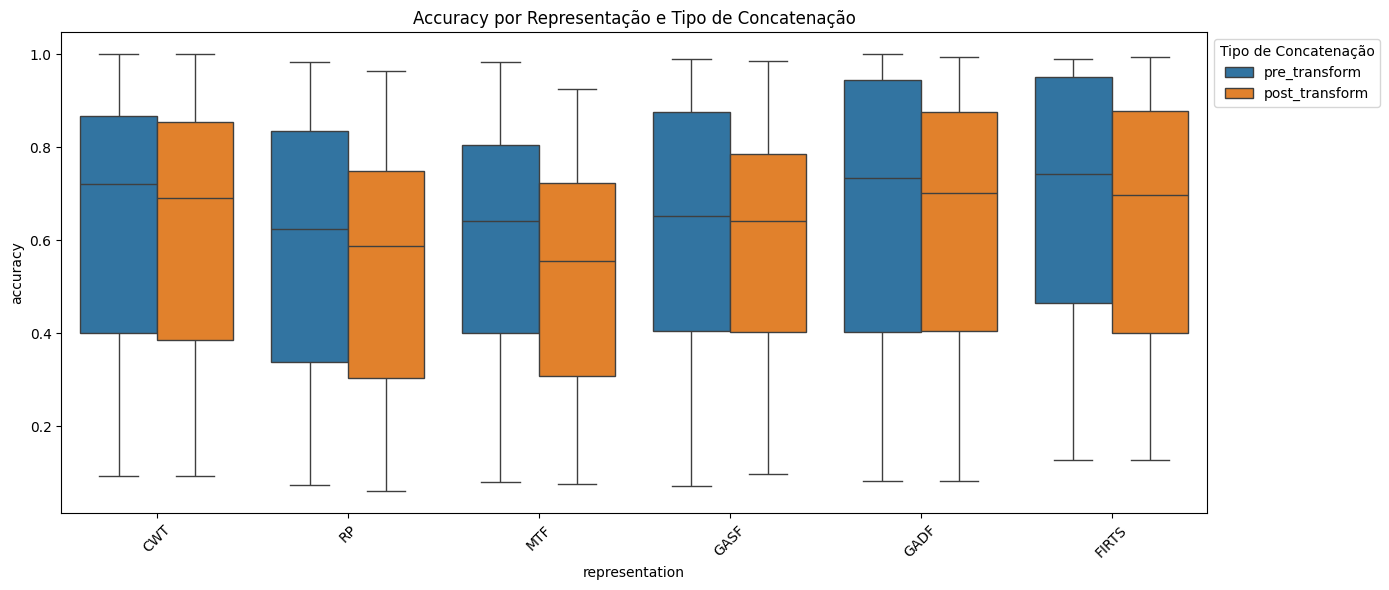

In [20]:
plt.figure(figsize=(14, 6))
plt.xticks(rotation=45)

sns.boxplot(x="representation", y="accuracy", hue="concatenation_type", data=df)

plt.legend(title='Tipo de Concatenação', loc='upper left', bbox_to_anchor=(1, 1))
plt.title("Accuracy por Representação e Tipo de Concatenação")
plt.tight_layout()
plt.show()

## Por representação e algoritmo de convolução

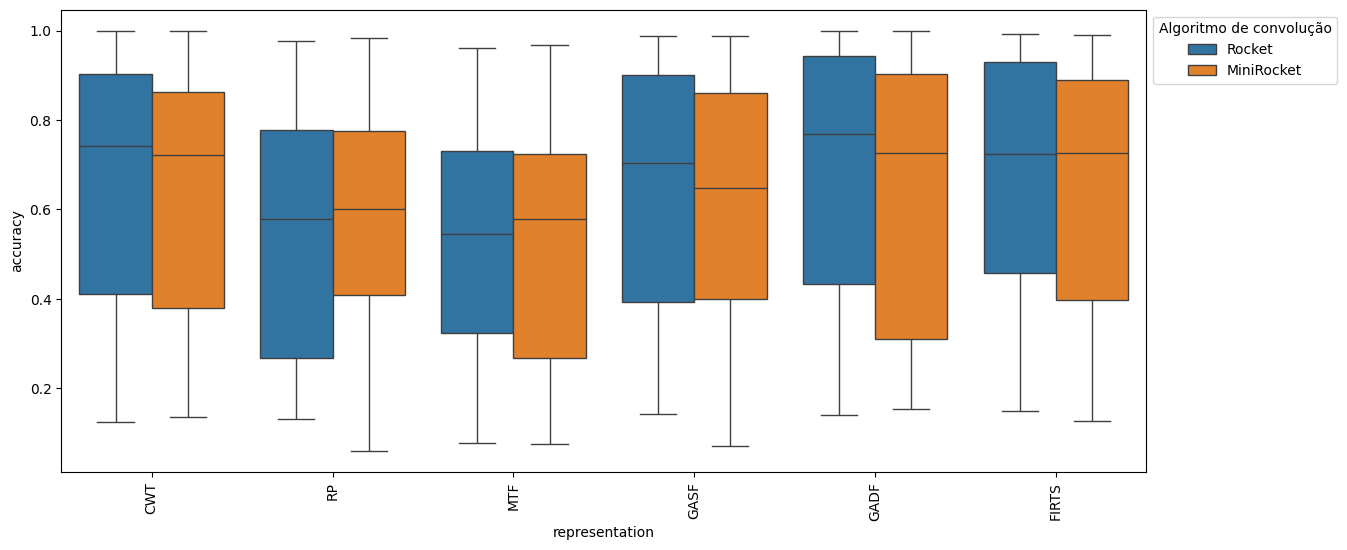

In [21]:
plt.figure(figsize=(14, 6))
plt.xticks(rotation=90)

sns.boxplot(x="representation", y="accuracy", hue="convolution_algorithm", data=df)

plt.legend(title='Algoritmo de convolução', loc='upper left', bbox_to_anchor=(1, 1))

plt.show()

## Por tipo de concatenação e algoritmo de convolução

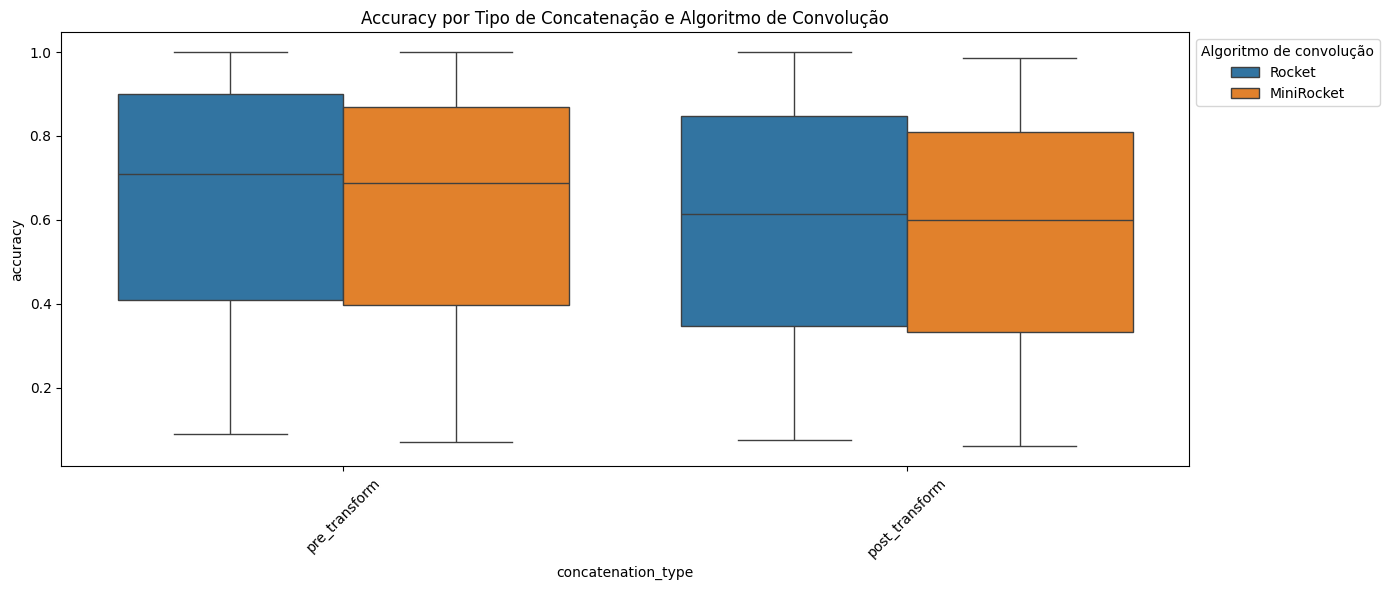

In [22]:
plt.figure(figsize=(14, 6))
plt.xticks(rotation=45)

sns.boxplot(x="concatenation_type", y="accuracy", hue="convolution_algorithm", data=df)

plt.legend(title='Algoritmo de convolução', loc='upper left', bbox_to_anchor=(1, 1))
plt.title("Accuracy por Tipo de Concatenação e Algoritmo de Convolução")
plt.tight_layout()
plt.show()

## Por algoritmo de classificação

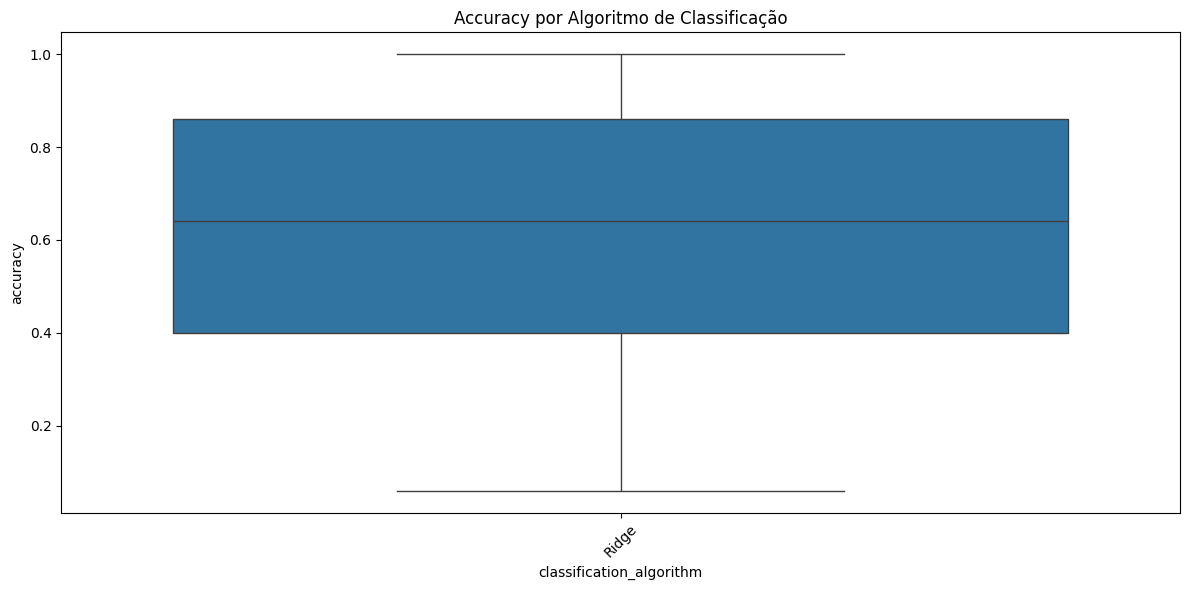

In [23]:
plt.figure(figsize=(12, 6))
sns.boxplot(x="classification_algorithm", y="accuracy", data=df)
plt.title("Accuracy por Algoritmo de Classificação")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Análise de Tempos de Execução

### Tempo de transformação de representação

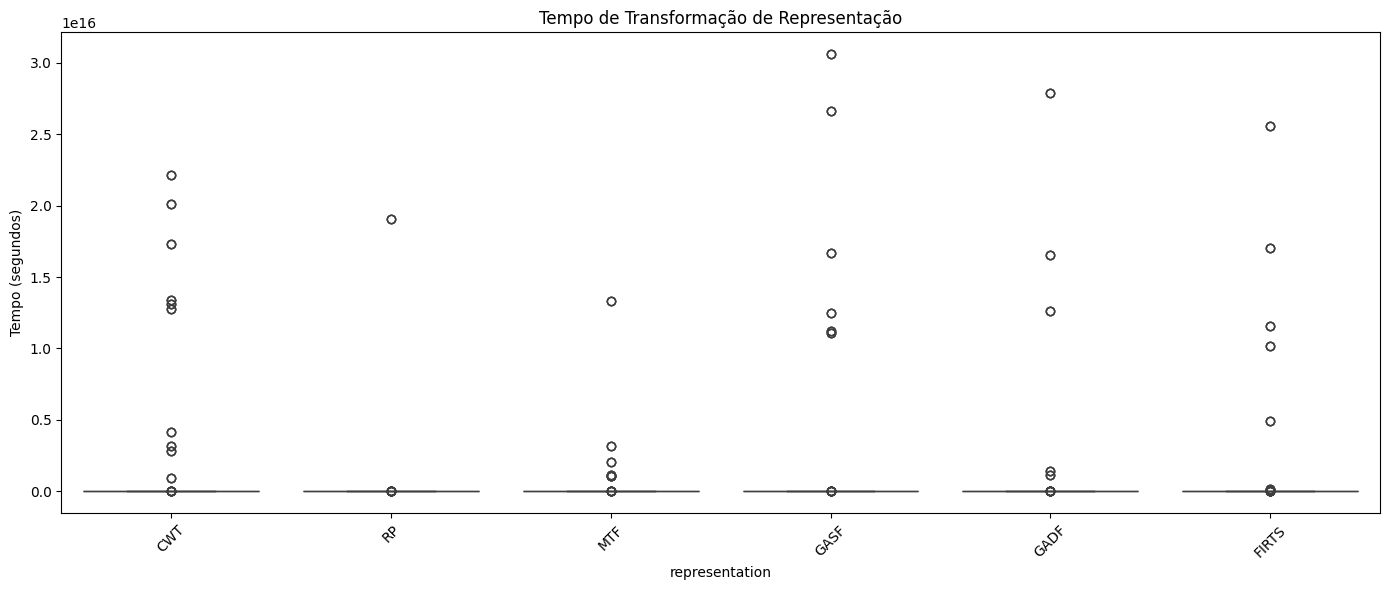

In [24]:
plt.figure(figsize=(14, 6))
sns.boxplot(x="representation", y="representation_transform_time", data=df)
plt.title("Tempo de Transformação de Representação")
plt.xticks(rotation=45)
plt.ylabel("Tempo (segundos)")
plt.tight_layout()
plt.show()

### Tempo de convolução

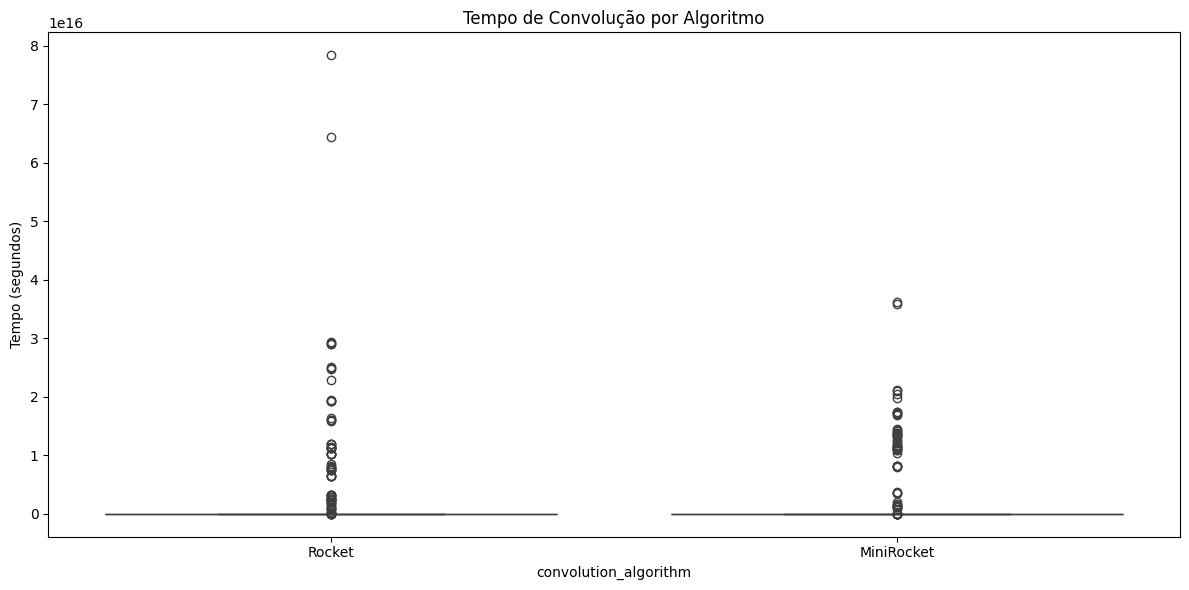

In [25]:
plt.figure(figsize=(12, 6))
# Filtrar apenas dados onde há tempo de convolução (não é 0)
df_conv = df[df['convolution_time'] > 0]
sns.boxplot(x="convolution_algorithm", y="convolution_time", data=df_conv)
plt.title("Tempo de Convolução por Algoritmo")
plt.ylabel("Tempo (segundos)")
plt.tight_layout()
plt.show()

## Resumo Estatístico

In [ ]:
print("=== ACCURACY POR REPRESENTAÇÃO ===")
accuracy_by_rep = df.groupby('representation')['accuracy'].agg(['mean', 'std', 'min', 'max', 'count'])
print(accuracy_by_rep.round(4))

print("\n=== ACCURACY POR ALGORITMO DE CONVOLUÇÃO ===")
accuracy_by_conv = df.groupby('convolution_algorithm')['accuracy'].agg(['mean', 'std', 'min', 'max', 'count'])
print(accuracy_by_conv.round(4))

print("\n=== ACCURACY POR TIPO DE CONCATENAÇÃO ===")
accuracy_by_concat = df.groupby('concatenation_type')['accuracy'].agg(['mean', 'std', 'min', 'max', 'count'])
print(accuracy_by_concat.round(4))

print("\n=== MELHOR CONFIGURAÇÃO POR DATASET ===")
best_config = df.loc[df.groupby('dataset')['accuracy'].idxmax()][['dataset', 'representation', 'concatenation_type', 'convolution_algorithm', 'accuracy']]
print(best_config.sort_values('accuracy', ascending=False))

=== ACCURACY POR REPRESENTAÇÃO ===
                  mean     std     min     max  count
representation                                       
CWT             0.6304  0.2734  0.0928  1.0000    159
FIRTS           0.6466  0.2853  0.1271  0.9933    159
GADF            0.6489  0.2834  0.0833  1.0000    159
GASF            0.6153  0.2693  0.0706  0.9903    159
MTF             0.5535  0.2581  0.0753  0.9833    159
RP              0.5751  0.2653  0.0600  0.9833    159

=== ACCURACY POR ALGORITMO DE CONVOLUÇÃO ===
                         mean     std     min  max  count
convolution_algorithm                                    
MiniRocket             0.6030  0.2782  0.0600  1.0    318
Rocket                 0.6214  0.2763  0.0765  1.0    318

=== ACCURACY POR TIPO DE CONCATENAÇÃO ===
                      mean     std     min  max  count
concatenation_type                                    
post_transform      0.5933  0.2661  0.0600  1.0    468
pre_transform       0.6293  0.2810  0.0706  1.0

## (Tentativa de) Scatterplots da Acurácia

### Acurácia por Representação

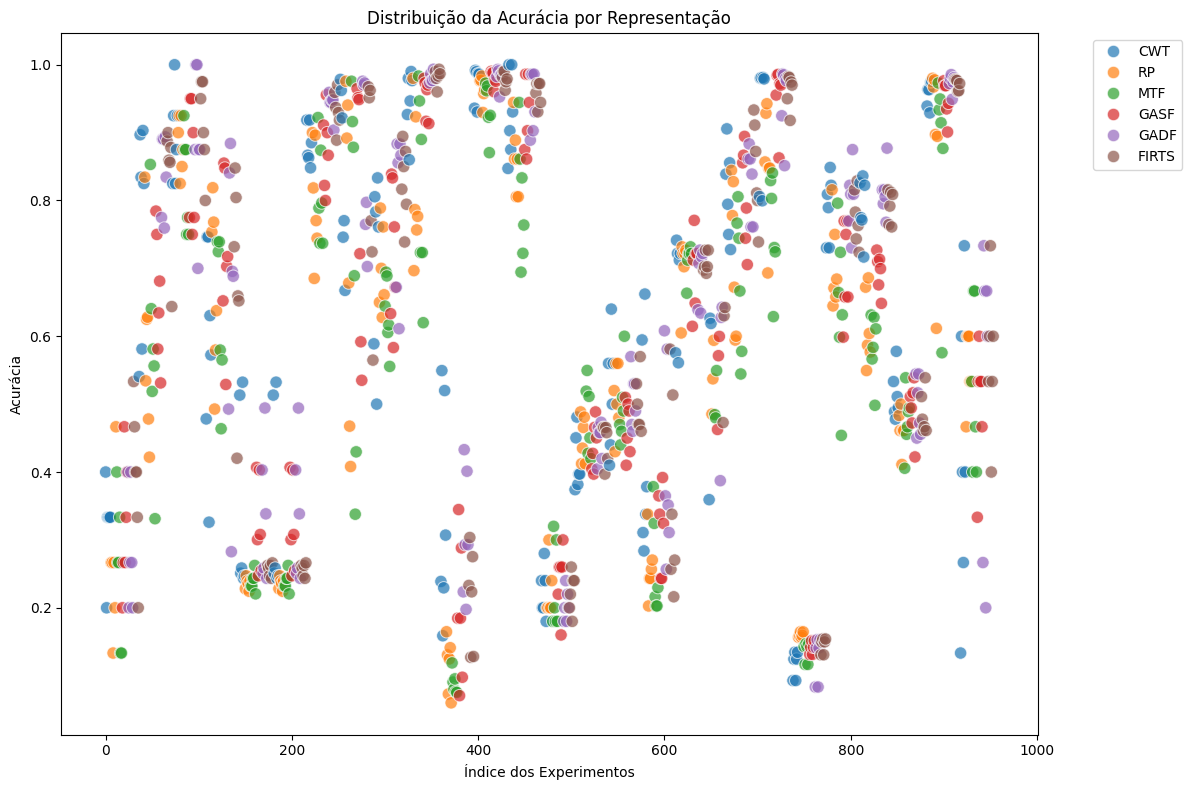

In [ ]:
plt.figure(figsize=(12, 8))

sns.scatterplot(data=df, x=df.index, y='accuracy', 
                hue='representation', s=80, alpha=0.7)

plt.title('Distribuição da Acurácia por Representação')
plt.xlabel('Índice dos Experimentos')
plt.ylabel('Acurácia')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Acurácia por Dataset

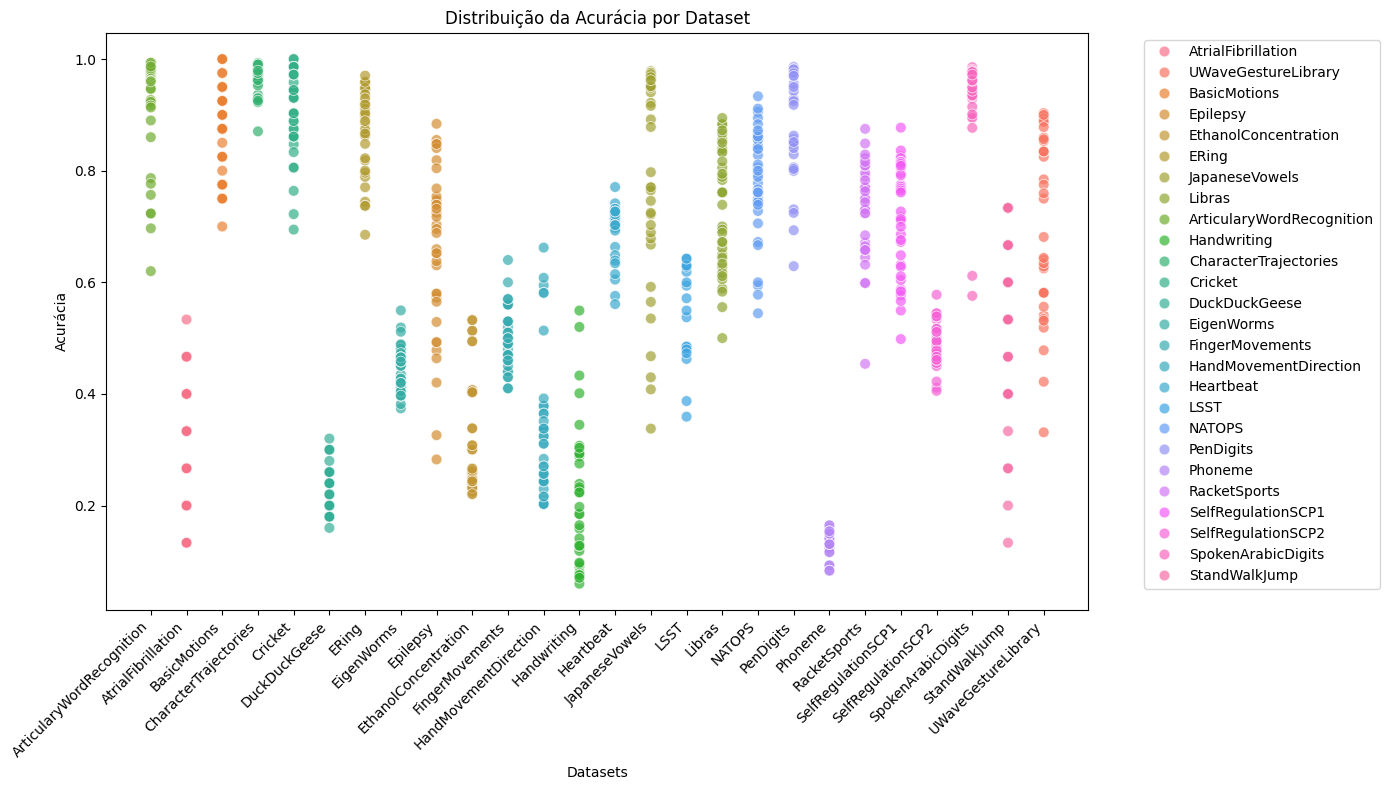

In [ ]:
plt.figure(figsize=(14, 8))

df_copy = df.copy()
datasets_unique = sorted(df['dataset'].unique())
dataset_codes = {dataset: i for i, dataset in enumerate(datasets_unique)}
df_copy['dataset_code'] = df_copy['dataset'].map(dataset_codes)

sns.scatterplot(data=df_copy, x='dataset_code', y='accuracy', 
                hue='dataset', s=60, alpha=0.7)

plt.title('Distribuição da Acurácia por Dataset')
plt.xlabel('Datasets')
plt.ylabel('Acurácia')
plt.xticks(range(len(datasets_unique)), datasets_unique, rotation=45, ha='right')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Acurácia por Algoritmo de Convolução

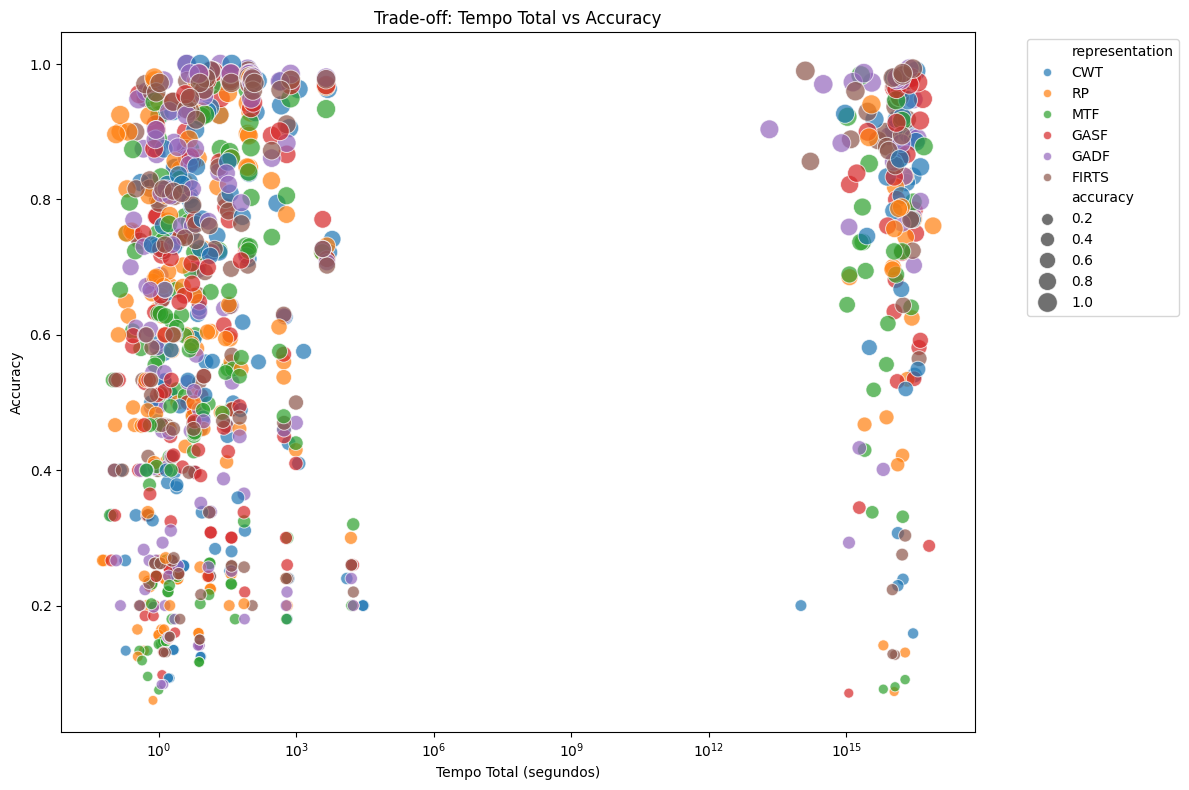

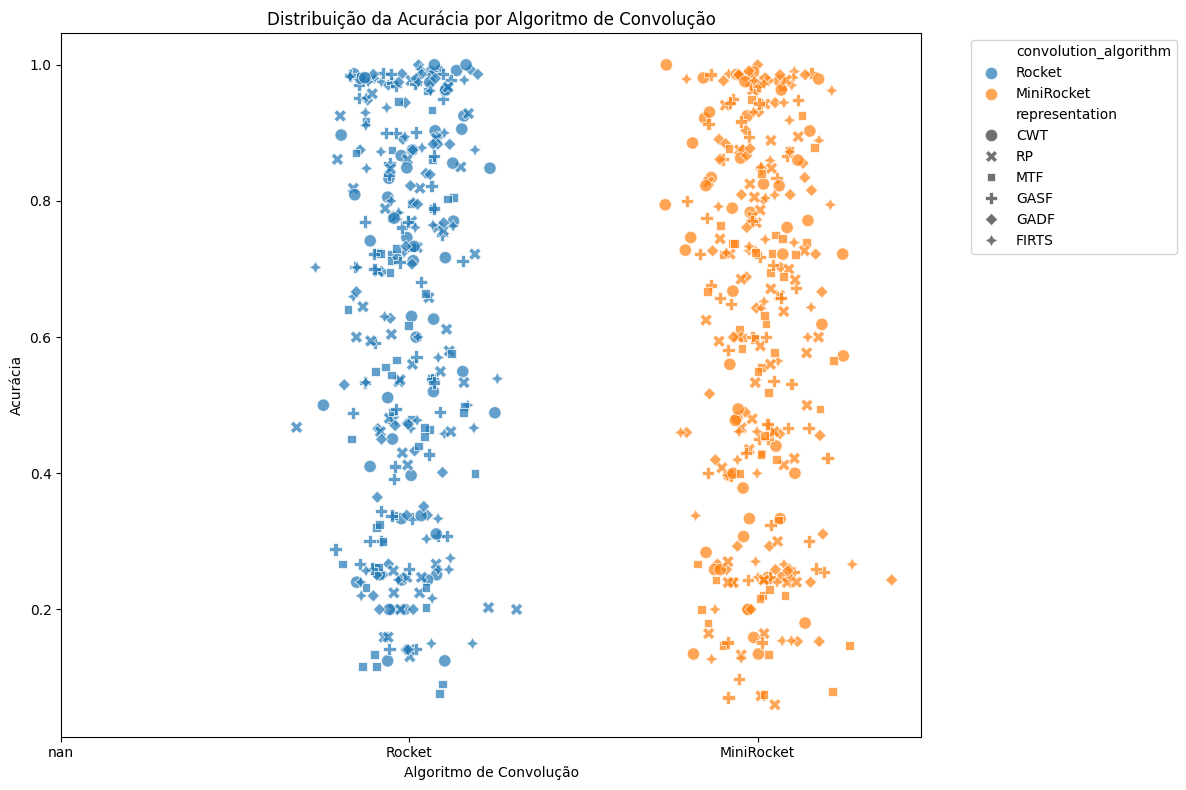

In [ ]:
# Criar uma coluna de tempo total
df['total_time'] = df['representation_transform_time'] + df['convolution_time'] + df['train_time'] + df['validation_time']

plt.figure(figsize=(12, 8))

sns.scatterplot(data=df, x='total_time', y='accuracy', 
                hue='representation', size='accuracy',
                sizes=(50, 200), alpha=0.7)

plt.title('Trade-off: Tempo Total vs Accuracy')
plt.xlabel('Tempo Total (segundos)')
plt.ylabel('Accuracy')
plt.xscale('log')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 8))

# adicionar um pouco de jitter no eixo x para evitar overplotting
np.random.seed(42)
df_jitter = df.copy()

conv_algorithms = df['convolution_algorithm'].unique()
conv_positions = {alg: i for i, alg in enumerate(conv_algorithms)}
df_jitter['conv_position'] = df_jitter['convolution_algorithm'].map(conv_positions)

df_jitter['conv_position_jitter'] = df_jitter['conv_position'] + np.random.normal(0, 0.1, len(df_jitter))

sns.scatterplot(data=df_jitter, x='conv_position_jitter', y='accuracy', 
                hue='convolution_algorithm', style='representation',
                s=80, alpha=0.7)

plt.title('Distribuição da Acurácia por Algoritmo de Convolução')
plt.xlabel('Algoritmo de Convolução')
plt.ylabel('Acurácia')
plt.xticks(range(len(conv_algorithms)), conv_algorithms)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Análise de Correlação Simples

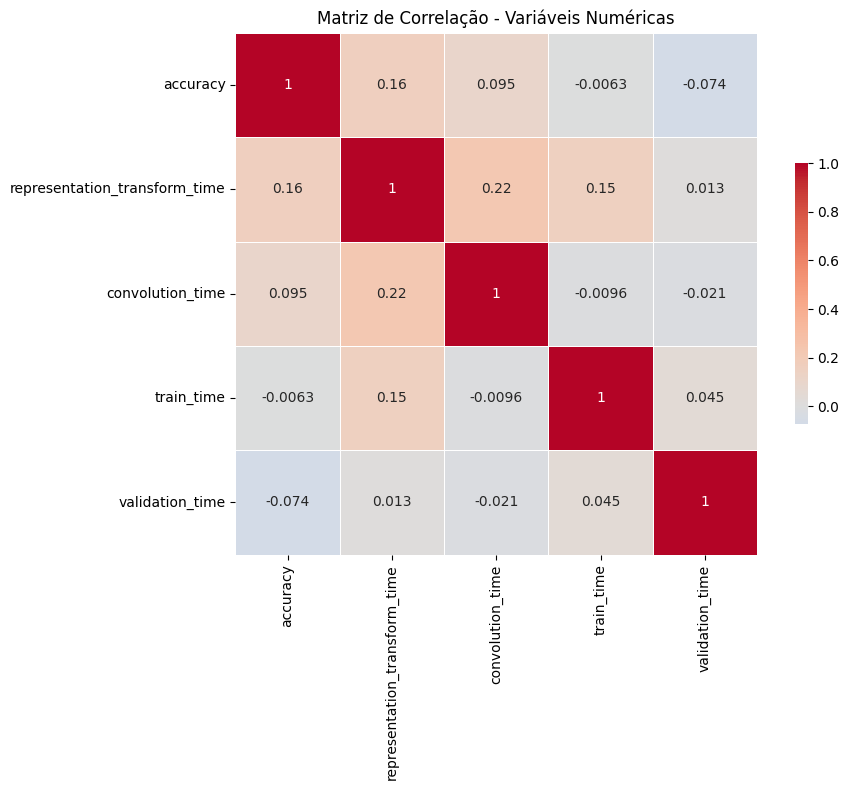

Correlações com a acurácia:
accuracy                         1.000000
representation_transform_time    0.158778
convolution_time                 0.094722
train_time                      -0.006272
validation_time                 -0.073848
Name: accuracy, dtype: float64


In [33]:
# Criar matriz de correlação simples (mais eficiente que pairplot)
numeric_cols = ['accuracy', 'representation_transform_time', 'convolution_time', 
                'train_time', 'validation_time']

# Calcular correlação
correlation_matrix = df[numeric_cols].corr()

# Plotar heatmap de correlação
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": .5})
plt.title('Matriz de Correlação - Variáveis Numéricas')
plt.tight_layout()
plt.show()

print("Correlações com a acurácia:")
print(correlation_matrix['accuracy'].sort_values(ascending=False))

### Scatterplot Simples por Configuração


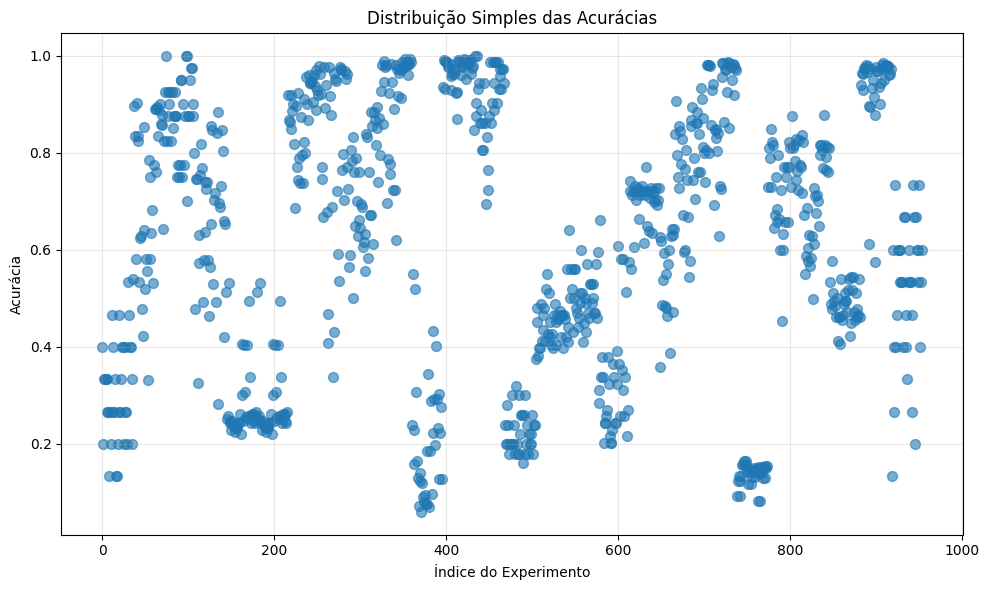

Total de experimentos: 954
Range de acurácia: 0.0600 - 1.0000


In [34]:
# Scatterplot mais simples - apenas pontos da acurácia
plt.figure(figsize=(10, 6))

# Plot simples com todas as acurácias
plt.scatter(range(len(df)), df['accuracy'], alpha=0.6, s=50)

plt.title('Distribuição Simples das Acurácias')
plt.xlabel('Índice do Experimento')
plt.ylabel('Acurácia')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Total de experimentos: {len(df)}")
print(f"Range de acurácia: {df['accuracy'].min():.4f} - {df['accuracy'].max():.4f}")